# Data Analysis for Churn Prediction
Analyze customer behavior to use on the churn prediction model.

# 0. Import Libraries and Load Data

In [157]:
# Data analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder

sns.set_theme()

In [47]:
df = pd.read_csv("../data/Telco_customer_churn.csv")

# Cast total charges to float
df['TotalCharges'] = df['TotalCharges'].replace(' ', 0).astype(float)

print(df.shape)
display(df)

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


# 1. General Analysis
Variable names, types, ranges, % of nulls and duplicates check.

In [48]:
print(df.info())
print(len(df.drop_duplicates(subset=['customerID'])))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [49]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [172]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_cols = [col for col in df.columns if col not in numerical_cols if col != 'customerID' and col != 'Churn']

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn_bin']


In [15]:
for col in categorical_cols:
    print(f"Amount of unique values in '{col}': {df[col].nunique()}")

Amount of unique values in 'customerID': 7043
Amount of unique values in 'gender': 2
Amount of unique values in 'SeniorCitizen': 2
Amount of unique values in 'Partner': 2
Amount of unique values in 'Dependents': 2
Amount of unique values in 'PhoneService': 2
Amount of unique values in 'MultipleLines': 3
Amount of unique values in 'InternetService': 3
Amount of unique values in 'OnlineSecurity': 3
Amount of unique values in 'OnlineBackup': 3
Amount of unique values in 'DeviceProtection': 3
Amount of unique values in 'TechSupport': 3
Amount of unique values in 'StreamingTV': 3
Amount of unique values in 'StreamingMovies': 3
Amount of unique values in 'Contract': 3
Amount of unique values in 'PaperlessBilling': 2
Amount of unique values in 'PaymentMethod': 4
Amount of unique values in 'Churn': 2


No nulls, duplicates or outliers.

# 2. Current KPIs Values
Churn rate, MRR and LTV.

## 2. 1. Churn Rate

In [18]:
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Current value is ~26,54%.

## 2. 2. MRR (Monthly Recurring Revenue)

In [ ]:
print(df['MonthlyCharges'].sum())
print(df[df['Churn'] == 'No']['MonthlyCharges'].sum())
print(df[df['Churn'] == 'Yes']['MonthlyCharges'].sum())

456116.6
316985.75
139130.85


Mean MRR: US$ 456,116.6 <br />
Active customer base mean MRR: US$ 316,985.75 <br />
Lost customer mean MRR: US$ 139,130.85 <br />

## 2. 3. LTV (Lifetime Value)

In [69]:
print(df[df['Churn'] == 'No']['TotalCharges'].mean())

2549.911441824507


Mean LTV: US$ 2.549,91

# 3. Distributions

## 3. 1. Churn (target)

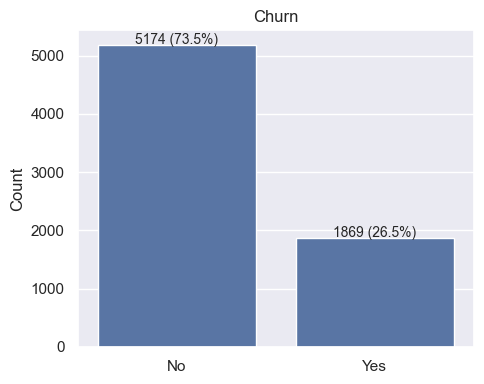

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [78]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['Churn'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('Churn')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Not-so-extreme unbalanced data. Maybe it will not be needed to use SMOTE or another techniques.

## 3. 2. Gender

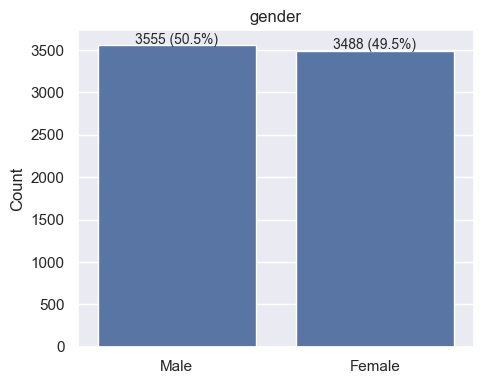

gender
Male      3555
Female    3488
Name: count, dtype: int64


In [79]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['gender'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('gender')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 3. Senior Citizen

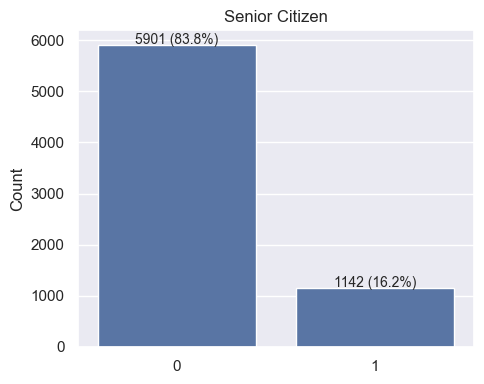

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64


In [81]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['SeniorCitizen'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('Senior Citizen')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most aren't senior citizens.

## 3. 4. Partner

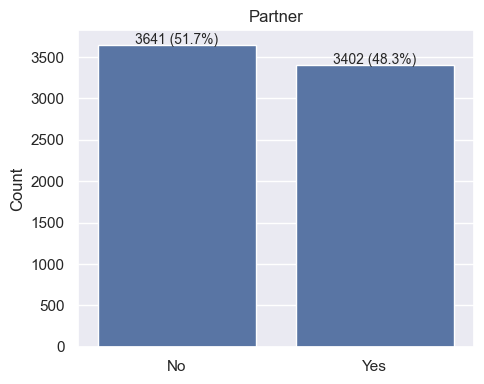

Partner
No     3641
Yes    3402
Name: count, dtype: int64


In [82]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['Partner'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('Partner')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 5. Dependents

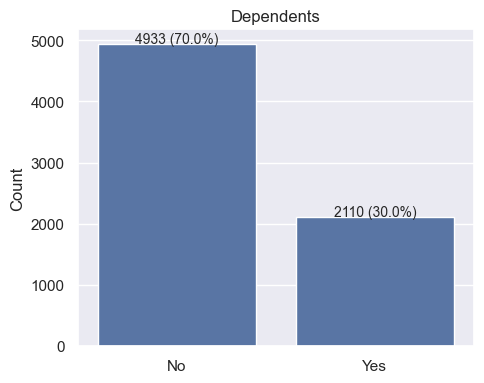

Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [83]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['Dependents'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('Dependents')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most don't have dependents.

## 3. 6. tenure

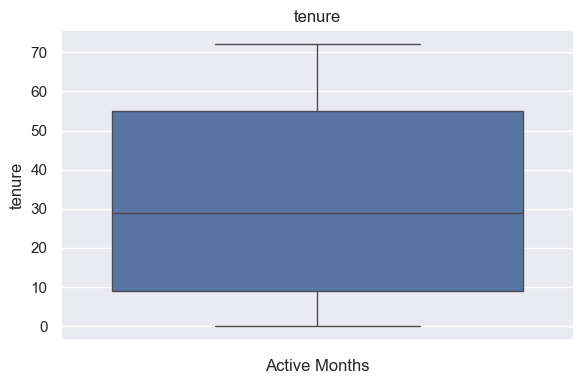

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64
Skew: 0.24
Kurtosis: -1.39


In [87]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(y=df['tenure'], ax=ax)

ax.set_title('tenure')
ax.set_xlabel('Active Months')

plt.tight_layout()
plt.show()

print(df['tenure'].describe())
print(f"Skew: {df['tenure'].skew():.2f}")
print(f"Kurtosis: {df['tenure'].kurt():.2f}")

## 3. 7. PhoneService

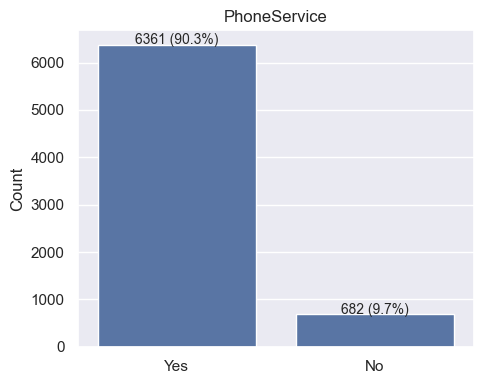

PhoneService
Yes    6361
No      682
Name: count, dtype: int64


In [88]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['PhoneService'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('PhoneService')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most have a phone service.

## 3. 8. MultipleLines

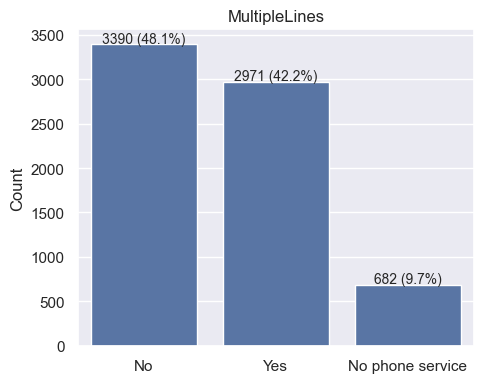

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


In [89]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['MultipleLines'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('MultipleLines')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 9. InternetService

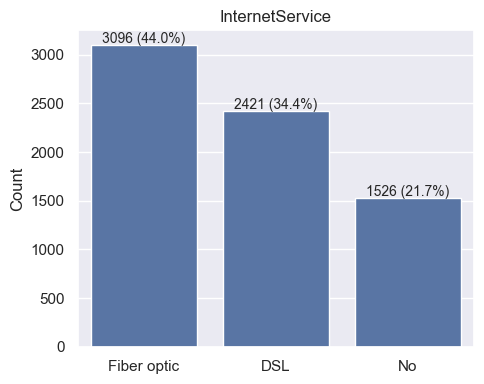

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


In [90]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['InternetService'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('InternetService')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 10. OnlineSecurity

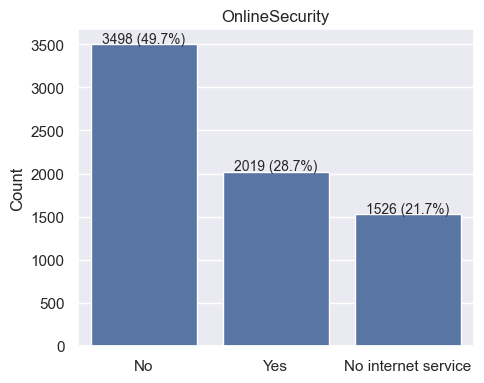

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [91]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['OnlineSecurity'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('OnlineSecurity')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most don't have an internet security service.

## 3. 11. OnlineBackup

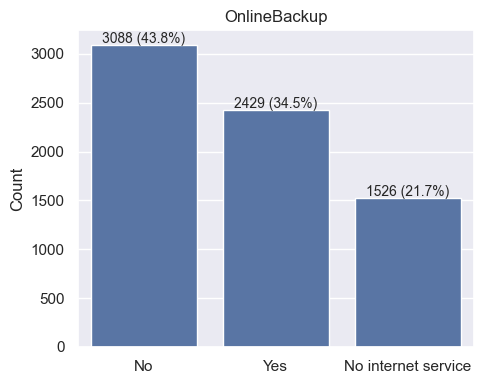

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


In [92]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['OnlineBackup'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('OnlineBackup')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most don't have an online backup service.

## 3. 12. DeviceProtection

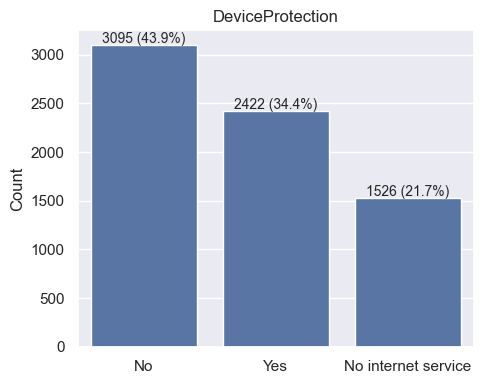

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


In [93]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['DeviceProtection'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('DeviceProtection')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most don't have.

## 3. 13. TechSupport

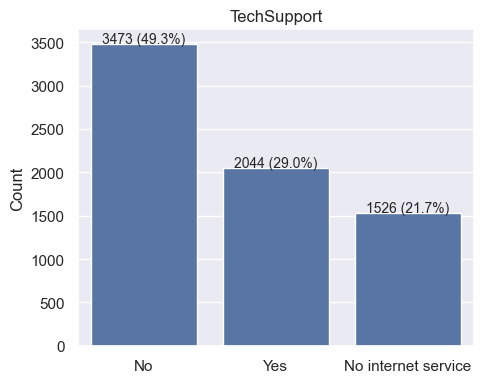

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


In [94]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['TechSupport'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('TechSupport')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

Most don't have.

## 3. 14. StreamingTV

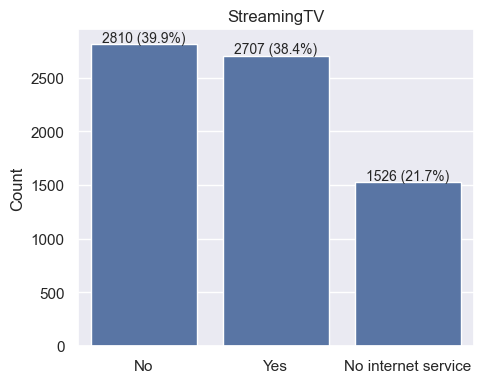

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


In [95]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['StreamingTV'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('StreamingTV')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 15. StreamingMovies

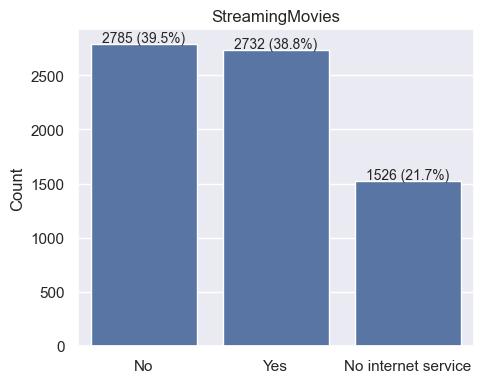

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


In [96]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['StreamingMovies'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('StreamingMovies')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 16. PaperlessBilling

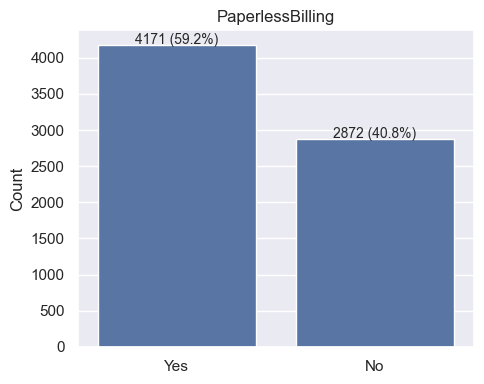

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64


In [97]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df['PaperlessBilling'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('PaperlessBilling')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 17. PaymentMethod

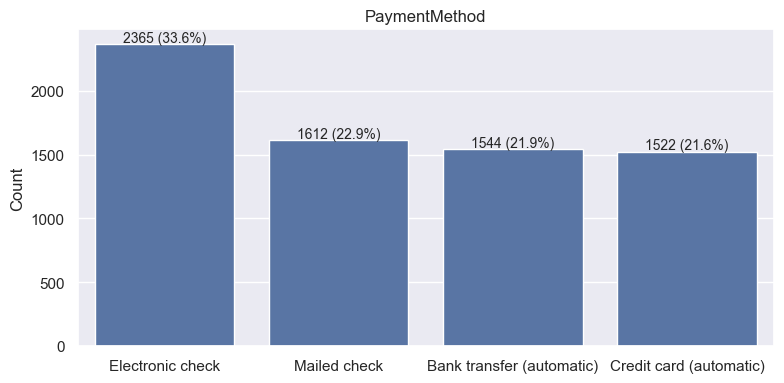

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [99]:
fig, ax = plt.subplots(figsize=(8, 4))

counts = df['PaymentMethod'].value_counts()

sns.barplot(x=counts.index, y=counts.values, ax=ax)

ax.set_title('PaymentMethod')

ax.set_xlabel('')

ax.set_ylabel('Count')

for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f'{v} ({v/len(df):.1%})', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(counts)

## 3. 18. MonthlyCharges

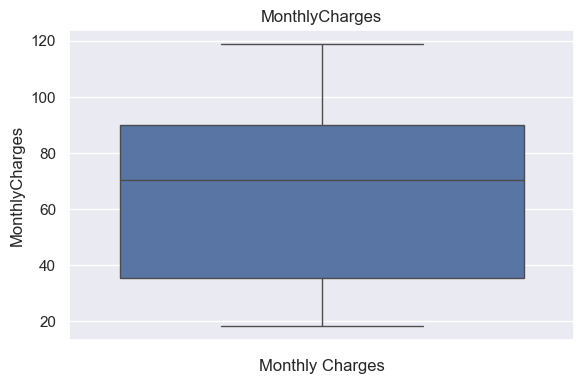

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64
Skew: -0.22
Kurtosis: -1.26


In [100]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(y=df['MonthlyCharges'], ax=ax)

ax.set_title('MonthlyCharges')
ax.set_xlabel('Monthly Charges')

plt.tight_layout()
plt.show()

print(df['MonthlyCharges'].describe())
print(f"Skew: {df['MonthlyCharges'].skew():.2f}")
print(f"Kurtosis: {df['MonthlyCharges'].kurt():.2f}")

## 3. 19. TotalCharges

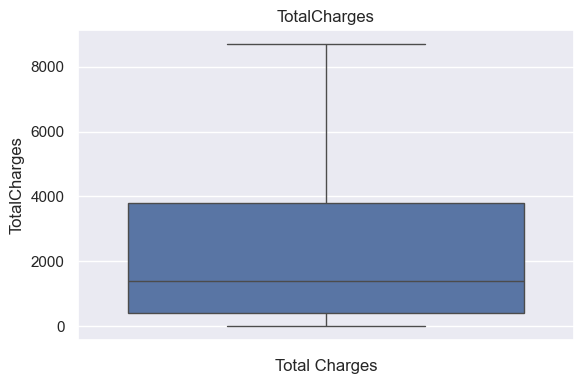

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64
Skew: 0.96
Kurtosis: -0.23


In [101]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(y=df['TotalCharges'], ax=ax)

ax.set_title('TotalCharges')
ax.set_xlabel('Total Charges')

plt.tight_layout()
plt.show()

print(df['TotalCharges'].describe())
print(f"Skew: {df['TotalCharges'].skew():.2f}")
print(f"Kurtosis: {df['TotalCharges'].kurt():.2f}")

Bit more skewed. May need log transformation.

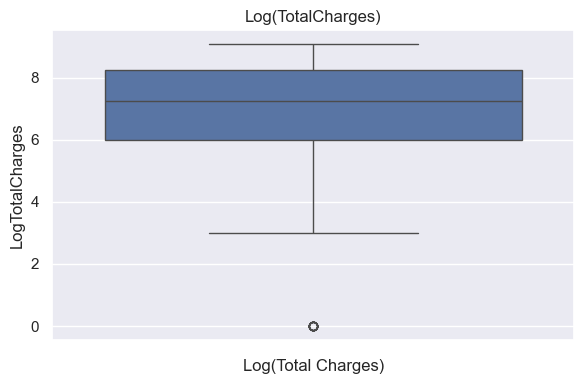

count    7043.000000
mean        6.932543
std         1.569371
min         0.000000
25%         5.990339
50%         7.241044
75%         8.239488
max         9.069445
Name: LogTotalCharges, dtype: float64
Skew: -0.82
Kurtosis: 0.10


In [102]:
aux = df.copy()
aux['LogTotalCharges'] = np.log1p(aux['TotalCharges'])

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(y=aux['LogTotalCharges'], ax=ax)

ax.set_title('Log(TotalCharges)')
ax.set_xlabel('Log(Total Charges)')

plt.tight_layout()
plt.show()

print(aux['LogTotalCharges'].describe())
print(f"Skew: {aux['LogTotalCharges'].skew():.2f}")
print(f"Kurtosis: {aux['LogTotalCharges'].kurt():.2f}")

Apparently no column needs special attention or transformations.

# 4. Correlations Between Features and Target Variable

## 4. 1. Gender

In [103]:
# Create a binary target variable for churn
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

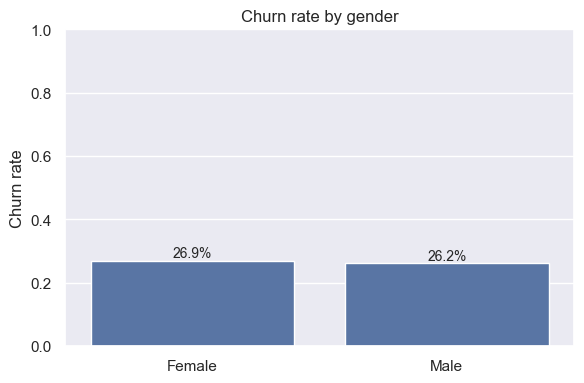

In [119]:
fig, ax = plt.subplots(figsize=(6, 4))

churn_rate = df.groupby('gender')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='gender', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by gender')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

No significant difference between females and males.

## 4. 2. SeniorCitizen

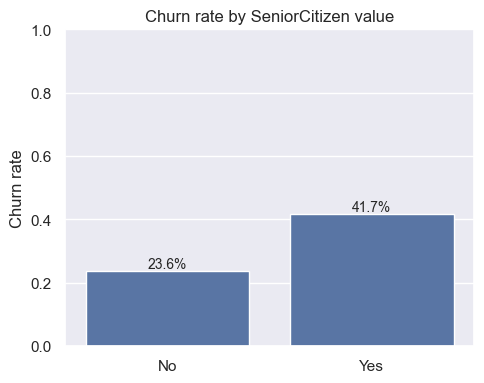

In [122]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('SeniorCitizen')['Churn_bin'].mean().reset_index()

churn_rate['SeniorCitizen'] = churn_rate['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

sns.barplot(data=churn_rate, x='SeniorCitizen', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by SeniorCitizen value')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

## 4. 3. Partner

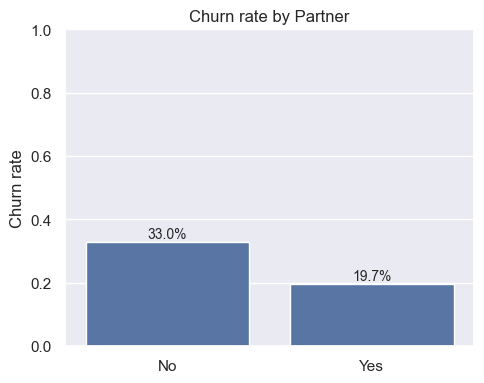

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('Partner')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='Partner', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by Partner')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Customers without partners churn more.

## 4. 4. Dependents

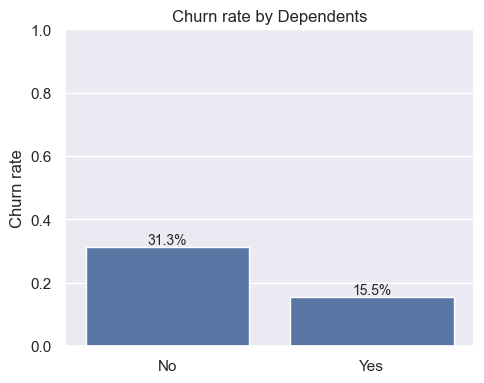

In [124]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('Dependents')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='Dependents', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by Dependents')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Customer without dependents churn more.

## 4. 5. tenure

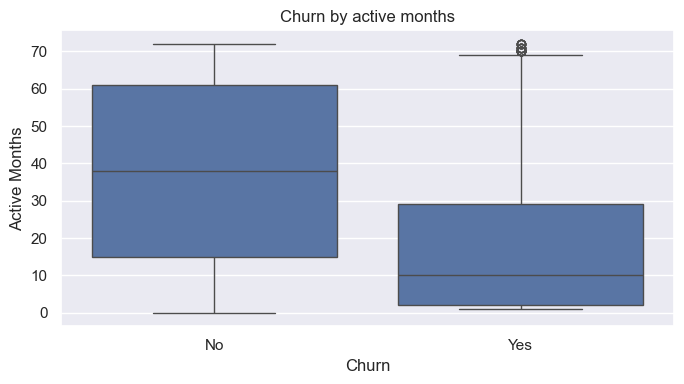

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [133]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=df, x='Churn', y='tenure', ax=ax)
ax.set_title('Churn by active months')
ax.set_ylabel('Active Months')
ax.set_xlabel('Churn')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].describe())

More recent customers tend to churn more.

## 4. 6. PhoneService

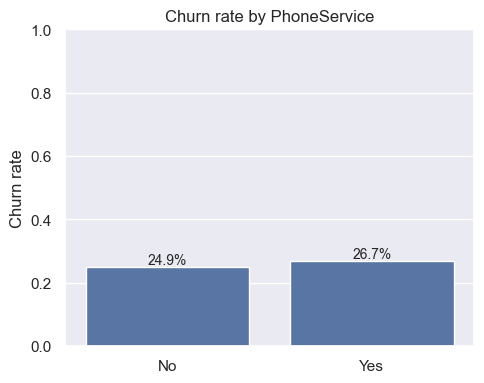

In [134]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('PhoneService')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='PhoneService', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by PhoneService')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

No big difference.

## 4. 7. MultipleLines

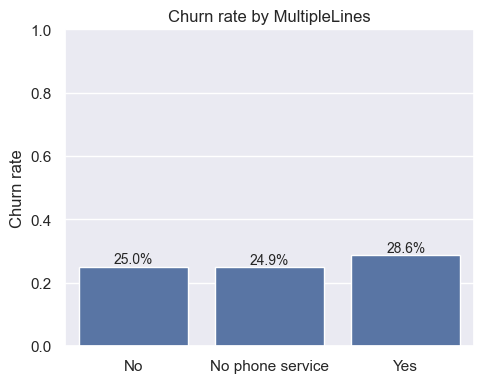

In [135]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('MultipleLines')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='MultipleLines', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by MultipleLines')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

No big difference.

## 4. 8. InternetService

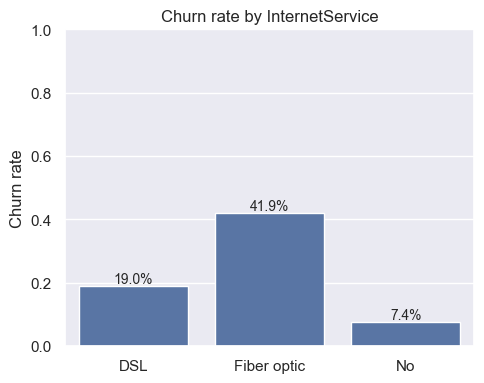

In [136]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('InternetService')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='InternetService', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by InternetService')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Customers with fiber optic churn more. Also customers with any internet service tend churn more than those who don't have one.

## 4. 9. OnlineSecurity

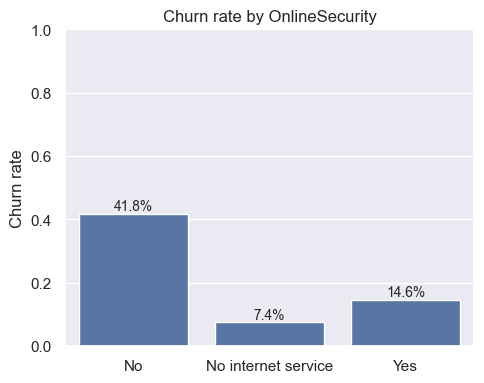

In [137]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('OnlineSecurity')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='OnlineSecurity', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by OnlineSecurity')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

The ones who don't have an online security churn more.

## 4. 10. OnlineBackup

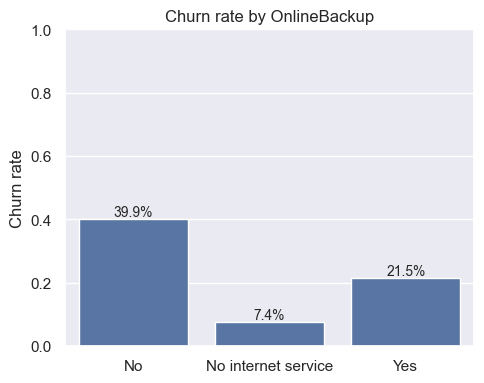

In [138]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('OnlineBackup')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='OnlineBackup', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by OnlineBackup')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

The ones with no online backup churn more.

## 4. 11. DeviceProtection

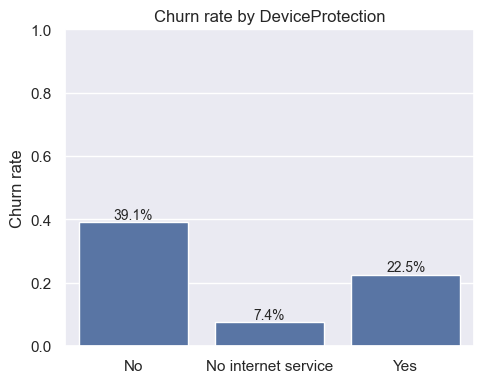

In [139]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('DeviceProtection')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='DeviceProtection', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by DeviceProtection')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

The ones with no device protection churn more.

## 4. 12. TechSupport

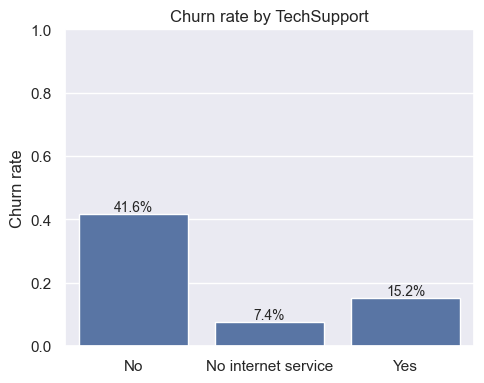

In [140]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('TechSupport')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='TechSupport', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by TechSupport')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

The ones with no tech support churn more.

## 4. 13. StreamingTV

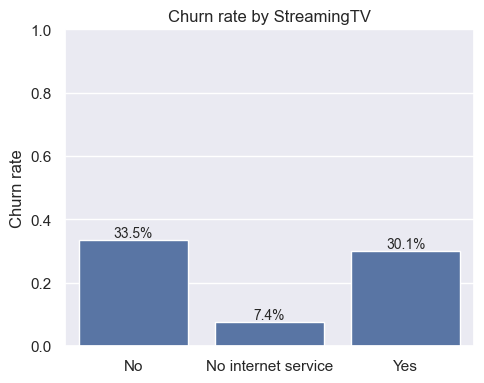

In [141]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('StreamingTV')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='StreamingTV', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by StreamingTV')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

No big difference between the customers that have and don't have streaming.

## 4. 14. StreamingMovies

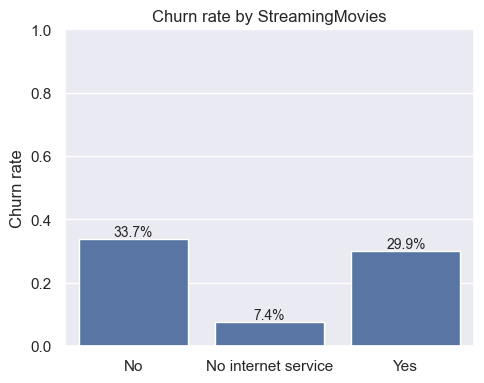

In [142]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('StreamingMovies')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='StreamingMovies', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by StreamingMovies')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

No big difference.

## 4. 15. Contract

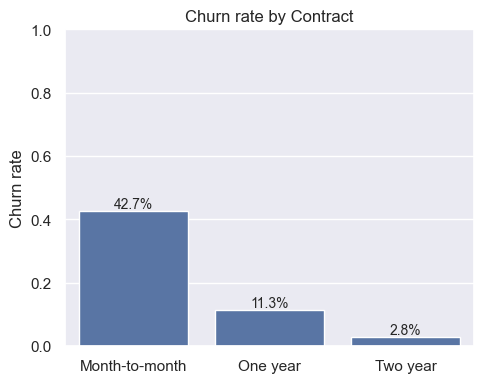

In [143]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('Contract')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='Contract', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by Contract')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Customers with month-to-month contract churn more.

## 4. 16. PaperlessBilling

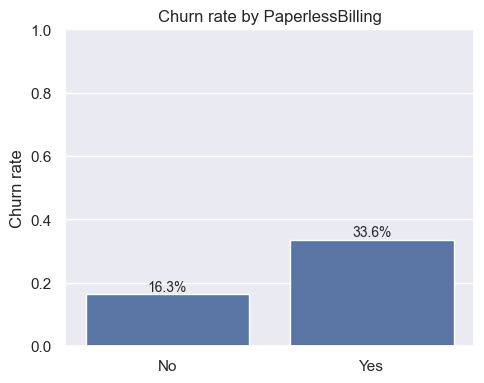

In [144]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_rate = df.groupby('PaperlessBilling')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='PaperlessBilling', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by PaperlessBilling')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Customers with paperless billing churn more.

## 4. 17. PaymentMethod

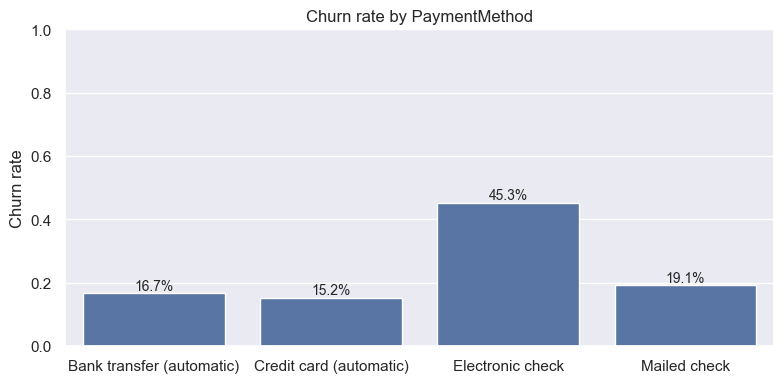

In [147]:
fig, ax = plt.subplots(figsize=(8, 4))

churn_rate = df.groupby('PaymentMethod')['Churn_bin'].mean().reset_index()

sns.barplot(data=churn_rate, x='PaymentMethod', y='Churn_bin', ax=ax)

ax.set_title('Churn rate by PaymentMethod')
ax.set_ylabel('Churn rate')
ax.set_xlabel('')
ax.set_ylim(0, 1)

for i, row in churn_rate.iterrows():
    ax.text(i, row['Churn_bin'] + 0.01, f"{row['Churn_bin']:.1%}", ha='center', fontsize=10)
    
plt.tight_layout()
plt.show()

Customers with electronic check payment method churn more.

## 4. 18. MonthlyCharges

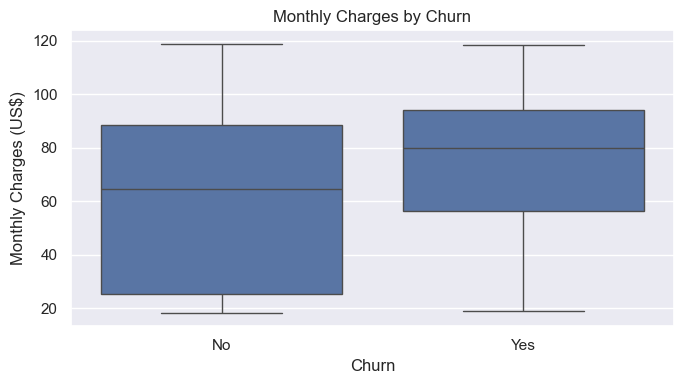

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [149]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax)

ax.set_title('Monthly Charges by Churn')
ax.set_ylabel('Monthly Charges (US$)')
ax.set_xlabel('Churn')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].describe())

Customers that churn have a bit greater monthly charge than those who don't.

## 4. 19. TotalCharges

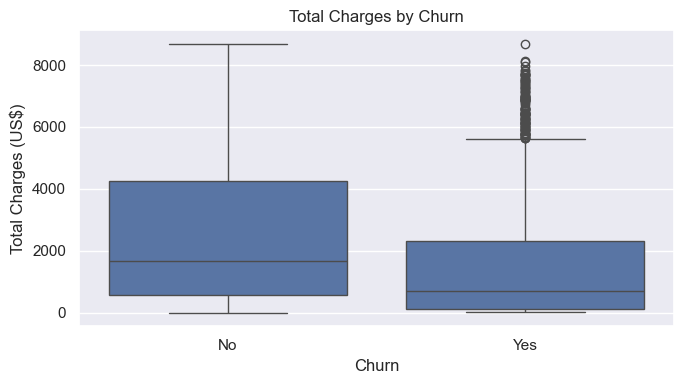

        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
Churn           
No     8672.45  
Yes    8684.80  


In [150]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=ax)

ax.set_title('Total Charges by Churn')
ax.set_ylabel('Total Charges (US$)')
ax.set_xlabel('Churn')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['TotalCharges'].describe())

Customers that churn have a smaller total charged value than those who don't.

# 5. Colinearity Analysis

## 5. 1. Between Numerical Variables

### 5. 1. 1. Pearson Corerlation

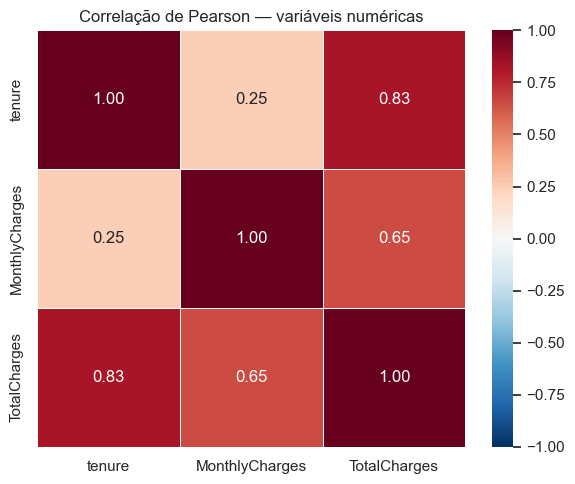

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.247900      0.826178
MonthlyCharges  0.247900        1.000000      0.651174
TotalCharges    0.826178        0.651174      1.000000


In [ ]:
corr = df[numerical_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Pearson Correlation Matrix')

plt.tight_layout()
plt.show()

print(corr)

### 5. 1. 2. Variance Inflation Factor


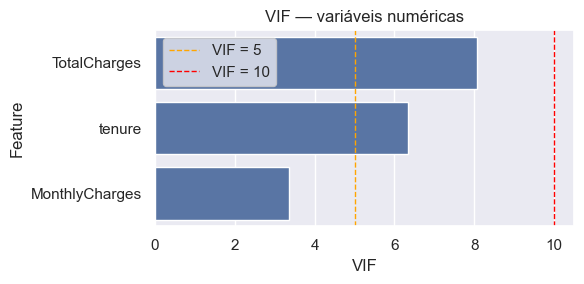

       Feature      VIF
  TotalCharges 8.075070
        tenure 6.332328
MonthlyCharges 3.355660


In [158]:
df_vif = df[numerical_cols].dropna()

vif_data = pd.DataFrame({
    'Feature': numerical_cols,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
}).sort_values('VIF', ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(data=vif_data, x='VIF', y='Feature', ax=ax)
ax.axvline(x=5,  color='orange', linestyle='--', linewidth=1, label='VIF = 5')
ax.axvline(x=10, color='red',    linestyle='--', linewidth=1, label='VIF = 10')
ax.set_title('VIF — variáveis numéricas')
ax.legend()
plt.tight_layout()
plt.show()

print(vif_data.to_string(index=False))

Big correlation between tenure and monthly/total charges.

## 5. 2. Numerical x Categorical

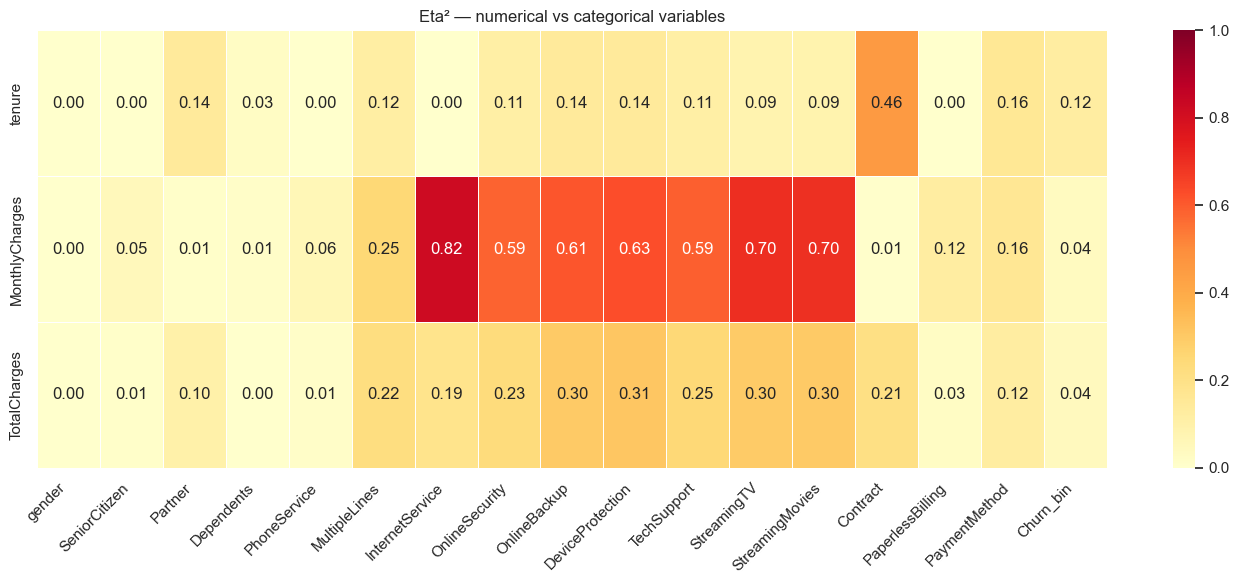

Pairs with Eta² > 0.14 (large effect):
      numerica       categorica     eta2
MonthlyCharges  InternetService 0.820698
MonthlyCharges      StreamingTV 0.700912
MonthlyCharges  StreamingMovies 0.697856
MonthlyCharges DeviceProtection 0.626117
MonthlyCharges     OnlineBackup 0.609498
MonthlyCharges      TechSupport 0.590512
MonthlyCharges   OnlineSecurity 0.585005
        tenure         Contract 0.456791
  TotalCharges DeviceProtection 0.308890
  TotalCharges  StreamingMovies 0.300590
  TotalCharges     OnlineBackup 0.297616
  TotalCharges      StreamingTV 0.296617
MonthlyCharges    MultipleLines 0.253707
  TotalCharges      TechSupport 0.246159
  TotalCharges   OnlineSecurity 0.233172
  TotalCharges    MultipleLines 0.219840
  TotalCharges         Contract 0.207266
  TotalCharges  InternetService 0.185393
MonthlyCharges    PaymentMethod 0.161021
        tenure    PaymentMethod 0.159864
        tenure          Partner 0.144170
        tenure DeviceProtection 0.141362
        tenure    

In [178]:
def eta_squared(cat_series, num_series):
    groups = [num_series[cat_series == cat].dropna() for cat in cat_series.unique()]
    grand_mean = num_series.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total   = ((num_series - grand_mean) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else 0

eta_matrix = pd.DataFrame(index=numerical_cols, columns=categorical_cols, dtype=float)

for num in numerical_cols:
    for cat in categorical_cols:
        eta_matrix.loc[num, cat] = eta_squared(df[cat].astype(str), df[num].dropna())

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    eta_matrix.astype(float),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Eta² — numerical vs categorical variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

eta_long = eta_matrix.astype(float).stack().reset_index()
eta_long.columns = ['numerica', 'categorica', 'eta2']
strong_eta = eta_long[eta_long['eta2'] > 0.14].sort_values('eta2', ascending=False)
print('Pairs with Eta² > 0.14 (large effect):')
print(strong_eta.to_string(index=False))

## 5. 3. Unified Correlation Matrix

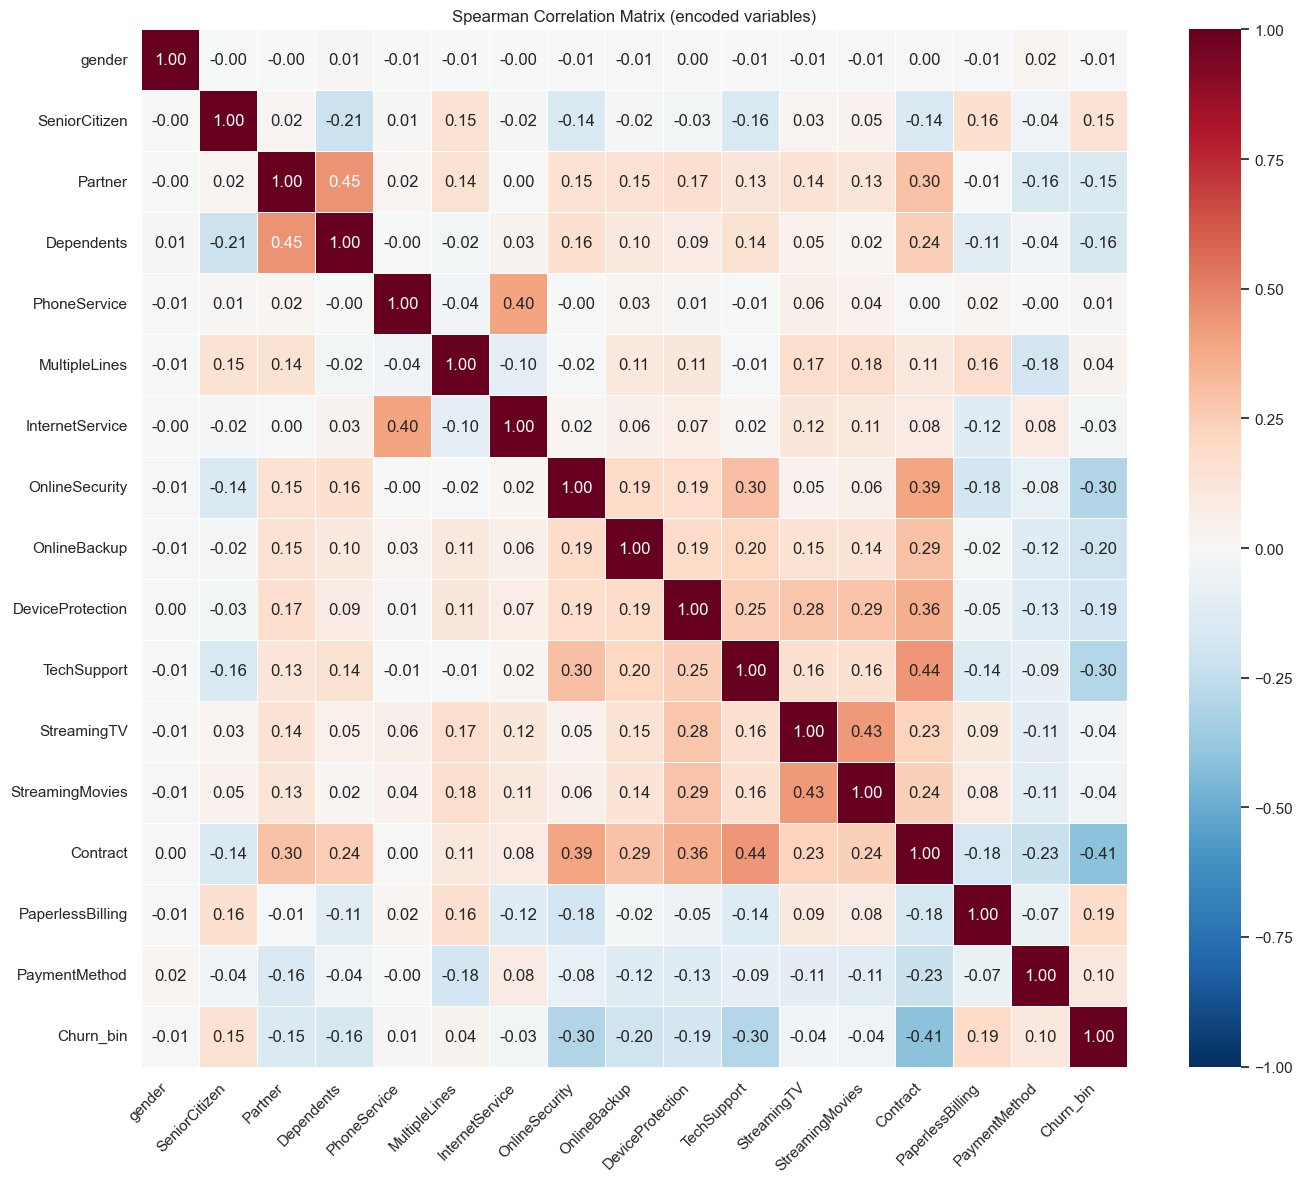

Top 15 most correlated pairs:
           var1             var2  spearman
     Dependents          Partner  0.452676
       Contract      TechSupport  0.440338
StreamingMovies      StreamingTV  0.434803
      Churn_bin         Contract -0.406262
InternetService     PhoneService  0.400349
       Contract   OnlineSecurity  0.392417
       Contract DeviceProtection  0.363058
      Churn_bin   OnlineSecurity -0.303918
    TechSupport   OnlineSecurity  0.303877
      Churn_bin      TechSupport -0.296815
       Contract          Partner  0.295925
       Contract     OnlineBackup  0.293445
StreamingMovies DeviceProtection  0.288430
    StreamingTV DeviceProtection  0.276711
    TechSupport DeviceProtection  0.248710


In [181]:
df_encoded = df[categorical_cols].copy()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[categorical_cols] = enc.fit_transform(df[categorical_cols].astype(str))
df_encoded = df_encoded.dropna()

corr_all = df_encoded.corr(method='spearman')  

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_all, dtype=bool), k=1)
sns.heatmap(
    corr_all,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Spearman Correlation Matrix (encoded variables)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

corr_pairs = (
    corr_all
    .where(np.tril(np.ones(corr_all.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'spearman']
corr_pairs['abs'] = corr_pairs['spearman'].abs()
print('Top 15 most correlated pairs:')
print(corr_pairs.sort_values('abs', ascending=False).head(15).drop(columns='abs').to_string(index=False))

# 6. Conclusions

The dataset has no data quality problems whatsoever (null, duplicates or outliers).
The variables don't seem to need any transformation.

**Churn profile**

Churn tends to concentrate in customers that:
- are senior citizens
- have no partner or dependents
- have been a customer for a short time (tenure)
- use fiber optic internet
- have no premium services (online security, backup, device protection, tech support)
- are on a monthly contract
- use paperless billing and electronic check as payment method
- have a higher monthly charge but lower total charge

In general, the churning customer can be characterized by: age group,
family situation, tenure, premium service adoption, contract/payment type,
and charge level.

The core pattern is: customers that find it easier to break the contract
tend to churn more — shorter tenure, no long-term contract, no bundled
services that create switching costs.

**Collinearity findings**

- PhoneService and MultipleLines are perfectly correlated by construction
  (multiple lines require phone service). Decision: drop PhoneService,
  keep MultipleLines.
- TotalCharges is structurally derived from tenure × MonthlyCharges,
  which explains their strong correlation. Decision: keep tenure and
  MonthlyCharges; consider dropping TotalCharges.
- InternetService is likely strongly correlated with its dependent
  services (OnlineSecurity, OnlineBackup, etc.) via the
  "No internet service" category — to be evaluated.

**Class balance**

The target variable shows a 25/75 split (churn vs. no churn).
This is a mild imbalance that may not require resampling techniques
such as SMOTE.